In [5]:
import os
import sqlite3
import warnings
from typing import Annotated,Literal

warnings.filterwarnings("ignore", message="The default value of `allowed_objects`")

from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from langchain_core.tools import InjectedToolCallId, tool
from langchain_openai import ChatOpenAI,OpenAIEmbeddings

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, MessagesState, StateGraph,START,END
from langgraph.prebuilt import InjectedState, ToolNode, tools_condition
from langgraph.types import Command
from pydantic import BaseModel, Field
from tavily import TavilyClient


from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

import operator

load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')
agent_model = ChatOpenAI(model = 'gpt-4o-mini')
base_embedding = OpenAIEmbeddings(model = 'text-embedding-3-small')



In [6]:
pdf_docs = PyPDFLoader(r'C:\Users\sajid\OneDrive\Desktop\RePaper\data\evs_oil_price_shock.pdf').load()
docs = RecursiveCharacterTextSplitter(chunk_size = 700,chunk_overlap = 150).split_documents(pdf_docs)

In [7]:
EMBEDDING_DIM = 1536
embedding_file_store = LocalFileStore("./embedding_cache")
embeddings = CacheBackedEmbeddings.from_bytes_store(
    base_embedding,
    embedding_file_store,
    namespace=base_embedding.model,
    query_embedding_cache=True,
    key_encoder='blake2b'
)

In [8]:
client = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"]
)

In [9]:
def get_vectorstore(collection_name):
    if not client.collection_exists(collection_name):
        client.create_collection(
            collection_name,
            vectors_config=VectorParams(size = EMBEDDING_DIM,distance=Distance.COSINE)
        )
    return QdrantVectorStore(
        client=client,
        collection_name = collection_name,
        embedding=embeddings
    )

In [10]:
vector_store = get_vectorstore('repaper')
# vector_store.add_documents(docs) 

In [11]:
# NEW
class claim_ev(BaseModel):
    title : str
    url : str
    summary : str
    
class claim_vardics(BaseModel):
    claim_verification_result : Literal['superseded','partially superseded','not superseded']
    claim_evidance : list[claim_ev]

In [12]:
class State(MessagesState):
    query : str
    
    retrieved_docs : list[Document]
    good_docs : list[Document]
    
    context : str
    route : Literal['retrieval','direct_generate','verify_claim']
    
    need_decomposition : bool
    decomposed_query : str
    
    tool_retries : int
    query_retries : int
    
    claim_verification_result : Literal['superseded','partially superseded','not superseded']
    claim_evidance : list[claim_ev]
    
    fallback : bool
    
    answer : str

In [13]:
@tool(response_format='content_and_artifact')
def vector_store_search(query : str, k : int =3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3 and retrieved max document must be less then 7) to retrieve more or fewer passages."""
    retriever = vector_store.as_retriever(search_kwargs={"k":k})
    retrieved_docs = retriever.invoke(query)
    
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in retrieved_docs)
    return context,retrieved_docs

In [14]:
@tool(response_format="content_and_artifact")
def web_search(query : str, k : int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3 and retrieved max result must be less then 7) to control how many results are returned."""
    client = TavilyClient()
    
    response = client.search(
        query=query,
        max_results=k
    )
    
    tavily_docs = []
    
    for resp in response["results"]:

        metadata = {
            "url": resp["url"],
            "title": resp["title"]
        }

        doc = Document(
            page_content=resp["content"],
            metadata=metadata
        )

        tavily_docs.append(doc)
        
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in tavily_docs)
    return context,tavily_docs

In [15]:
tools = [vector_store_search,web_search]
agent_model_with_tool = agent_model.bind_tools(tools)
tool_node = ToolNode(tools)

In [16]:
class RetrieveDecision(BaseModel):
    route : Literal['retrieval','direct_generate','verify_claim'] = Field(
        ...,
        description="'retrieval' if the query needs vector search or/and web search result to make context. 'direct_generate' if the parametric knowladge is enough to answer the query without any hellocination.'verify_claim' if the query ask any claim that need to be verified using web search and arxiv research paper search."
    )

    
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
        '''You are an intelligent routing agent for a Retrieval-Augmented Generation (RAG) system. Your primary task is to analyze incoming user queries and determine the optimal execution path. 

        Based on the nature of the query, you must classify it into exactly one of the following three routes:

        * **`direct_generate`**: Choose this route if your internal parametric knowledge is sufficient to answer the query accurately and completely. Use this for general knowledge, programming syntax, conversational greetings, or foundational concepts where there is zero risk of hallucination.
        * **`retrieval`**: Choose this route if the query requires pulling external context to answer accurately. Use this when the system needs to perform a vector database search or a general web search to gather missing facts, recent news, or specific document references.
        * **`verify_claim`**: Choose this route if the user is presenting a specific factual, scientific, or academic claim that requires rigorous validation. Use this when the system must cross-reference the query against specialized academic repositories (like arXiv) alongside general web searches to prove, disprove, or add nuance to the claim.

        Analyze the user's input carefully and output ONLY the precise string literal that matches the required route.''',
        ),
        ("human", "Question: {question}"),
    ]
)

def retrieval_path(state:State):
    query = state['query']
    chain = decide_retrieval_prompt | model.with_structured_output(RetrieveDecision)
    resp = chain.invoke({'question':query})
    return {'route':resp.route}



In [17]:
class DecomposeDecision(BaseModel):
    need_decompose : bool = Field(...,description="True if the query is complex and it need to decompose, else False.")
    
def check_decomposition(state:State):

    prompt = ChatPromptTemplate.from_messages([
        ('system',"You are a query analysis assistant. Determine if the user's question asks for "
            "multiple distinct pieces of information that each require separate retrieval. "
            "If yes, needs_decomposition should be True. "
            "If the question is simple or self-contained, needs_decomposition should be False."),
        ('human',"Query : {query}")
    ])
    chain = prompt | model.with_structured_output(DecomposeDecision)
    resp = chain.invoke({'query':state['query']})
    return {"need_decomposition": resp.need_decompose}




In [18]:
class DecomposeQueries(BaseModel):
    queries : list[str] = Field(description='Decompose the query into a list of subquries')

def decompose_query(state:State):
    query = state['query']
    decompose_prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query decomposition assistant. Break the user's question into focused, "
            "self-contained sub-queries — one per retrieval step. Each sub-query should target "
            "a single distinct piece of information."
        ),
        ("human", "{query}"),
    ])

    chain = decompose_prompt | model.with_structured_output(DecomposeQueries)
    resp = chain.invoke({'query':query})
    new_query = "\n".join(f"Step {i+1}: {q}" for i,q in enumerate(resp.queries))
    
    formatted = (
        f"You must call a retrieval tool for each of the following {len(resp.queries)} steps "
        f"before answering. Do not skip any step.\n\n{new_query}"
    )
    return {'decomposed_query': formatted}
    

In [19]:
CLAIM_ANALYSIS_PROMPT = (
    "You are a research fact-checker. Given a claim from a research paper and "
    "a set of recent web and arXiv search results, determine:\n"
    "1. Has this claim been superseded, significantly challenged, or updated by more recent work?\n"
    "2. Identify up to 3 papers from the provided results that supersede or update the claim.\n\n"
    "Rules:\n"
    "- Use ONLY titles and URLs that appear verbatim in the provided search results.\n"
    "- Prefer arXiv paper links (arxiv.org) over general web links when available.\n"
    "- For each superseding paper, write one sentence explaining how it supersedes the claim.\n"
    "- If the claim still holds, set is_superseded=false and return an empty superseding_papers list.\n"
    "- verdict_summary should be 1-2 sentences suitable for display to the user."
)

def verify_claim(state:State):
    client = TavilyClient()
    web_response = client.search(
        max_results= 2,
        query=f"recent research superseding : {state['query'][:300]}"
    ).get('results',[])
    
    arxiv_response = client.search(
        max_results= 2,
        query=f"site:arxiv.org : {state['query'][:300]}"
    ).get('results',[])
    
    context = ['===== General web search result ======\n']
    for resp in web_response:
        context.append(
            f"Title : {resp.get('title','')}\n"
            f"url : {resp.get('url','')}\n"
            f"Snippet : {resp.get('content','')[:1000]}\n"
        )
        
    context.append("==== Arxiv paper search result ====")
    for resp in arxiv_response:
        context.append(
            f"Title : {resp.get('title','')}\n"
            f"url : {resp.get('url','')}\n"
            f"Snippet : {resp.get('content','')[:1000]}\n"
        )

    prompt = (
        f"{CLAIM_ANALYSIS_PROMPT}\n\n"
        f"Claim to verify:\n{state['query']}\n\n"
        f"Search Results:\n{context}"
    )
    
    resp = model.with_structured_output(claim_vardics).invoke(prompt)
    return {'claim_verification_result':resp.claim_verification_result,'claim_evidance':resp.claim_evidance}

In [20]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools.\n\n"
    "When the query contains numbered steps (e.g. Step 1: ..., Step 2: ...), each step is a separate "
    "retrieval sub-task. Make sure every step receives at least one retrieval call — do not skip or "
    "overlook any step. For each step, choose whichever tool or combination of tools best fits the "
    "information need; the retrieval path for each step is yours to decide."
)

def agent(state: State):
    history = state.get('messages', [])
    query = state.get("decomposed_query") or state['query']
    
    # 1. Dynamically build the system prompt with the current goal injected
    dynamic_system_prompt = f"""{AGENT_SYSTEM_PROMPT}

    CRITICAL INSTRUCTIONS:
    1. Your current retrieval target is: 
    {query}
    2. Review the tool outputs below. If the information needed is already present in the history, simply reply with 'All information retrieved.' and DO NOT call any more tools."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", dynamic_system_prompt),
        MessagesPlaceholder(variable_name="messages")
    ])
    
    chain = prompt | agent_model_with_tool
    
    resp = chain.invoke({'messages': history})
    
    return {'messages': [resp]}
    
    
    

In [21]:

def tool_use_limit(state:State):
    cnt = state.get('tool_retries',0)
    return {'tool_retries':cnt+1}
    

In [22]:
def collect_retrieved_docs(state:State):
    good_docs = []
    for doc in reversed(state['messages']):
        if isinstance(doc,HumanMessage):
            break
        if isinstance(doc,ToolMessage):
            good_docs.extend(doc.artifact)
    # print(good_docs)
    good_docs.reverse()
    return {'retrieved_docs':good_docs}
        

In [23]:
class relevency_schema(BaseModel):
    is_relevent: bool = Field(description="True if document is relevent to the query else False")
    
    
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)    
def fatch_relevent_docs(state:State):
    good_docs = []
    query = state.get('decomposed_query') or state['query']
    chain = is_relevant_prompt | model.with_structured_output(relevency_schema)
    
    for doc in state['retrieved_docs']:
        resp = chain.invoke({'question':query,'document':doc}).is_relevent
        if resp:
            good_docs.append(doc)
    # print(good_docs)
    context = '\n\n'.join(d.page_content for d in good_docs)

    return {'good_docs':good_docs,'context':context}

In [24]:
def modify_query(state:State):
    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query rewriting assistant. A retrieval system searched for information to answer the user's "
            "query but none of the retrieved documents were relevant. Your task is to rewrite the query to be more "
            "specific, use different terminology, or focus on a narrower aspect that is more likely to match "
            "content in the knowledge source. Return only the rewritten query string."
        ),
        ("human", "Original query: {query}\n\nRewritten query:"),
    ])
    
    chain = prompt_template | model
    response = chain.invoke({"query": state["query"]})
    
    new_query = response.content.strip()
    
    cnt = state.get('query_retries',0)
    return {'decomposed_query':new_query,'query_retries':cnt+1}

In [25]:
MAX_QUERY_RETRIES = 3

In [26]:
def fallback_node(state:State):
    if state.get('query_retries',0) > MAX_QUERY_RETRIES:
        return {'fallback':True}
    return {}

In [27]:
def generate(state: State) -> dict:
    if state.get("fallback"):
        return {
            "answer": (
                "I was unable to find relevant information to answer your query after multiple retrieval attempts. "
                "The knowledge source does not appear to contain content that addresses this question."
            )
        }
    direct_generate_prompt = ChatPromptTemplate.from_messages([
        ("system", (
            "You are a helpful, highly knowledgeable AI assistant. "
            "Answer the user's query clearly and accurately based on your internal knowledge. "
            "If the request involves coding, provide clean, well-documented solutions."
        )),
        ("human", "{query}"),
    ])
    
    retrieval_prompt = ChatPromptTemplate.from_messages([
        ("system", (
            '''You are an AI assistant for question answering using retrieved context documents.

            Your task is to answer the user's question ONLY using the provided context. 
            Follow these rules strictly:

            1. Use only the information from the context.
            2. Do not use outside knowledge.
            3. If the answer is not contained in the context, say:
            "I could not find enough information in the provided context."
            4. Be concise but complete.
            5. When possible, cite which context chunk or source supports the answer.
            7. Do not hallucinate or invent facts.
            8. For research-related questions:
            - distinguish between claims, evidence, and conclusions
            - preserve technical accuracy'''
            "{context}"
        )),
        ("human", "Question: {query}"),
    ])
    
    
    verify_claim_prompt = ChatPromptTemplate.from_messages([
        ("system", (
            "You are an expert fact-checker and scientific research assistant. "
            "Your task is to verify the user's claim using ONLY the provided search results. "
            "The context includes general web searches and academic papers (arXiv).\n\n"
            "Analyze the context carefully and structure your response as follows:\n"
            "1. Verdict: (True / False / Partially True / Unverified)\n"
            "2. Analysis: Explain your reasoning, pointing out any consensus or contradictions "
            "3. You must provide 1-2 evidance along with correct url(if any) after completing the response if the evidance is provided else skip it."
            "between the academic papers and the general web results.\n\n"
            "Context:\n"
            "{context}\n"
            "Claim_verification_result:\n"
            "{result}"
        )),
        ("human", "Claim to verify: {query}"),
    ])
    
    if state['route'] == 'direct_generate':
        prompt_template = direct_generate_prompt
        invoke_kwargs = {'query':state['query']} 
    elif state['route'] == 'retrieval':
        prompt_template = retrieval_prompt
        invoke_kwargs = {'query':state['query'],'context':state.get('context','')}
    else:
        prompt_template = verify_claim_prompt
        invoke_kwargs = {'query':state['query'],'context':state.get("claim_evidance",''),'result':
            state.get('claim_verification_result','')}
        
    response = (prompt_template | model).invoke(invoke_kwargs)
    print(prompt_template.invoke(invoke_kwargs))
    return {"answer": response.content}

In [28]:
def need_retrieval_route(state:State) -> Literal['generate','check_decomposition','verify_claim']:
    if state['route'] == 'retrieval':
        return 'check_decomposition'
    elif state['route'] == "direct_generate":
        return 'generate'
    elif state['route'] == "verify_claim":
        return 'verify_claim'


def route_decompose(state:State)->Literal['agent','decompose_query']:
    if state['need_decomposition']:
        return 'decompose_query'
    return "agent"


def tool_call_route(state:State)->Literal['tool_node','collect_retrieved_docs']:
    return 'tool_node' if state['messages'][-1].tool_calls  else 'collect_retrieved_docs'

MAX_TOOL_CALL = 5

def tool_limit_route(state:State)->Literal['agent','collect_retrieved_docs']:
    return 'agent' if state['tool_retries'] < MAX_TOOL_CALL  else 'collect_retrieved_docs'



def check_relevence_route(state:State)->Literal['fallback_node','modify_query']:
    return 'fallback_node' if len(state.get('good_docs',[])) > 0 or state.get('query_retries', 0) > MAX_QUERY_RETRIES else 'modify_query'
    
    

In [29]:
graph = StateGraph(State)

graph.add_node('retrieval_path',retrieval_path)
graph.add_node('check_decomposition',check_decomposition)
graph.add_node('verify_claim',verify_claim)
graph.add_node('generate',generate)
graph.add_node('agent',agent)
graph.add_node('decompose_query',decompose_query)
graph.add_node('tool_node',tool_node)
graph.add_node('tool_use_limit',tool_use_limit)
graph.add_node('collect_retrieved_docs',collect_retrieved_docs)
graph.add_node('modify_query',modify_query)
graph.add_node('fatch_relevent_docs',fatch_relevent_docs)
graph.add_node('fallback_node',fallback_node)

graph.add_edge(START,'retrieval_path')
graph.add_conditional_edges('retrieval_path',need_retrieval_route)
graph.add_conditional_edges('check_decomposition',route_decompose)
graph.add_edge('decompose_query','agent') 
graph.add_conditional_edges('agent',tool_call_route) 
graph.add_edge('tool_node','tool_use_limit') 
graph.add_conditional_edges('tool_use_limit',tool_limit_route) 
graph.add_edge('collect_retrieved_docs','fatch_relevent_docs') 
graph.add_conditional_edges('fatch_relevent_docs',check_relevence_route) 
graph.add_edge('modify_query','agent')
graph.add_edge('verify_claim','generate') 
graph.add_edge('fallback_node','generate') 
graph.add_edge('generate',END) 

workflow = graph.compile()

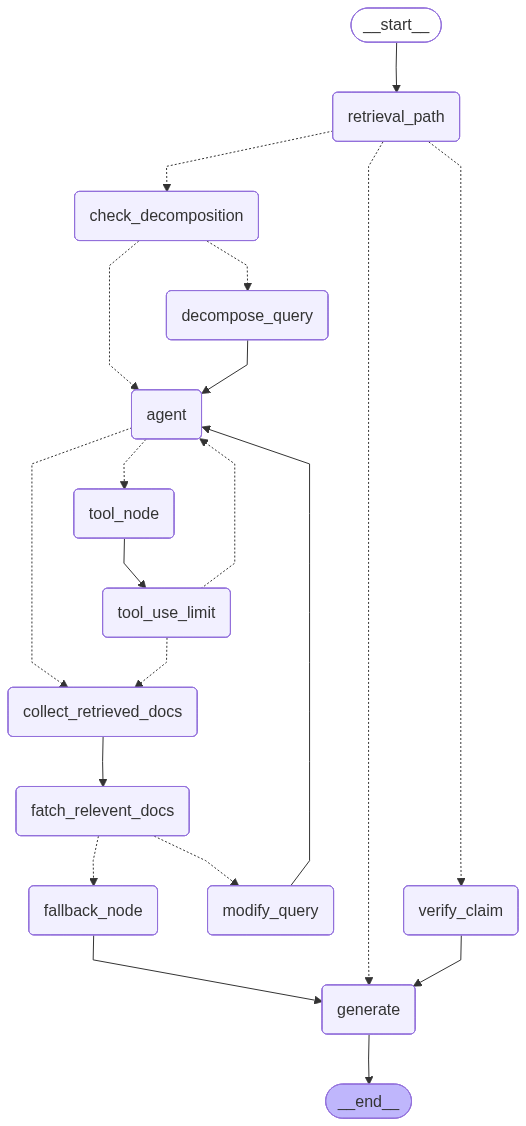

In [30]:
workflow

In [34]:
query_1 = (
   "what is the temp of today in dhaka"
)

result = workflow.invoke({
    "query": query_1,
    "messages": []
})

messages=[SystemMessage(content='You are an AI assistant for question answering using retrieved context documents.\n\n            Your task is to answer the user\'s question ONLY using the provided context. \n            Follow these rules strictly:\n\n            1. Use only the information from the context.\n            2. Do not use outside knowledge.\n            3. If the answer is not contained in the context, say:\n            "I could not find enough information in the provided context."\n            4. Be concise but complete.\n            5. When possible, cite which context chunk or source supports the answer.\n            7. Do not hallucinate or invent facts.\n            8. For research-related questions:\n            - distinguish between claims, evidence, and conclusions\n            - preserve technical accuracyToday\'s Condition: Dhaka. 36.9°C. 28.4°C ... Historical Temperature Data · Online Data Purchase · BMD Weather App · BMD Current Weather App · Mobile Website.\n

In [35]:
print(result['answer'])

The current temperature in Dhaka is 36.9°C (approximately 82°F), and the high and low temperatures today are 35°C and 27°C, respectively (context refers to current conditions and historical data).


In [33]:
result

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 496, 'total_tokens': 556, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_53ee395669', 'id': 'chatcmpl-DmBjqfcJVvJHWGed2ZEgwhmfI87w0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e86c0-f21a-7a23-9ebb-168889af005b-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': 'company leaving policy', 'k': 5}, 'id': 'call_YIHK9ontnDmhX1nGuuNmFpjt', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'company leave policy 2024', 'k': 5}, 'id': 'call_AgCaSAiDhsJrvUrlmyNENHbE', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad